# 🧠 Malagasy Morpheme Segmentation: Root Tagging Seq2Seq Model

Ce notebook implémente un modèle **Seq2Seq** au niveau des caractères capable de segmente les mots ET d'identifier la racine en l'entourant de crochets (ex: `miaboabo` ➔ `mi|[abo]|[abo]`).

In [1]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Limite fixe : 75% de 4096 Mo = 3072 Mo
        tf.config.set_logical_device_configuration(
            gpus[0],
            [tf.config.LogicalDeviceConfiguration(memory_limit=3072)]
        )
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(f"✅ GPU configuré avec limite mémoire : 3072 Mo (75% de 4096 Mo)")
        print(f"   Périphériques logiques : {logical_gpus}")
    except RuntimeError as e:
        print(f"⚠️  Erreur : {e}")
else:
    print("⚠️  Aucun GPU détecté — CPU utilisé.")


I0000 00:00:1774338911.884760   45724 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


⚠️  Aucun GPU détecté — CPU utilisé.


W0000 00:00:1774338917.192214   45724 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [4]:
import os
# Se placer dans le répertoire du notebook
os.chdir('/home/tovo/Bureau/DataML/lemmnation')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle
from sklearn.model_selection import train_test_split

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## 🏷️ 1. Chargement et Marquage des Racines (Target Tagging)

In [6]:
# Charger les deux datasets
df_morphs = pd.read_csv('data/malagasy_training_data.csv')
df_fused = pd.read_csv('data/malagasy_data_FINAL.csv')

# Fusionner pour avoir l'info de la racine pour chaque mot
df = pd.merge(df_morphs, df_fused[['word', 'root']], on='word', how='left').drop_duplicates()

def format_target_with_root(row):
    morphs = json.loads(row['morphemes'])
    root = str(row['root'])
    
    tagged_morphs = []
    for m in morphs:
        # Si le morphème est identique à la racine, on l'entoure de crochets
        if m == root:
            tagged_morphs.append(f"[{m}]")
        else:
            tagged_morphs.append(m)
            
    return "|".join(tagged_morphs)

df['target'] = df.apply(format_target_with_root, axis=1)
df['input'] = df['word']

print("Aperçu des données avec racines marquées :")
display(df[['input', 'target']].head(15))

Aperçu des données avec racines marquées :


,input,target
0,ababoka,a|[baboka]
1,ababoke,a|[baboke]
2,ababy,a|[baby]
3,abae,a|[bae]
4,abafoka,a|[bafoka]
5,abaha,a|[baha]
6,abahana,a|[bahana]
7,abaibay,a|[baibay]
8,abaikabaika,a|baika|baika
9,abaiko,a|[baiko]


In [7]:
def create_vocab(texts):
    vocab = set("".join(texts))
    char2idx = {char: i + 2 for i, char in enumerate(sorted(list(vocab)))}
    char2idx['<PAD>'] = 0
    char2idx['<SOS>'] = 1
    char2idx['<EOS>'] = len(char2idx)
    idx2char = {i: char for char, i in char2idx.items()}
    return char2idx, idx2char

char2idx, idx2char = create_vocab(df['input'].tolist() + df['target'].tolist())

VOCAB_SIZE = len(char2idx)
MAX_LEN_IN = df['input'].apply(len).max()
MAX_LEN_OUT = df['target'].apply(len).max() + 2

print(f"Vocab Size: {VOCAB_SIZE}")

Vocab Size: 29


In [9]:
def vectorize(texts, char2idx, max_len, add_sos=False, add_eos=False):
    seqs = []
    for text in texts:
        seq = []
        if add_sos: seq.append(char2idx['<SOS>'])
        for char in str(text):
            seq.append(char2idx.get(char, 0))
        if add_eos: seq.append(char2idx['<EOS>'])
        seqs.append(seq)
    return pad_sequences(seqs, maxlen=max_len, padding='post')

X = vectorize(df['input'].tolist(), char2idx, MAX_LEN_IN)
dec_in = vectorize(df['target'].tolist(), char2idx, MAX_LEN_OUT, add_sos=True)
dec_out = vectorize(df['target'].tolist(), char2idx, MAX_LEN_OUT, add_eos=True)

X_train, X_test, d_in_train, d_in_test, d_out_train, d_out_test = train_test_split(
    X, dec_in, dec_out, test_size=0.1, random_state=42
)

## 🏗️ 2. Architecture Seq2Seq

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

LATENT_DIM = 256
EMBEDDING_DIM = 64

# ENCODER
encoder_inputs = Input(shape=(MAX_LEN_IN,))
enc_emb = Embedding(VOCAB_SIZE, EMBEDDING_DIM, mask_zero=True)(encoder_inputs)
_, sh, sc = LSTM(LATENT_DIM, return_state=True)(enc_emb)
encoder_states = [sh, sc]

# DECODER
decoder_inputs = Input(shape=(None,))
dec_emb_layer = Embedding(VOCAB_SIZE, EMBEDDING_DIM, mask_zero=True)
dec_outputs, _, _ = LSTM(LATENT_DIM, return_sequences=True, return_state=True)(
    dec_emb_layer(decoder_inputs), initial_state=encoder_states
)
decoder_dense = Dense(VOCAB_SIZE, activation='softmax')
decoder_outputs = decoder_dense(dec_outputs)

model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Callbacks GPU-friendly
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True, verbose=1),
]


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 22)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 22, 64)    │      1,856 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 22)        │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, None, 64)  │      1,856 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 256),     │    328,704 │ embedding[0][0],  │
│                     │ (None, 256),      │            │ not_equal[0][0]   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, None,     │    328,704 │ embedding_1[0][0… │
│                     │ 256), (None,      │            │ lstm[0][1],       │
│                     │ 256), (None,      │            │ lstm[0][2]        │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, None, 29)  │      7,453 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 668,573 (2.55 MB)

 Trainable params: 668,573 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

## 🚀 3. Entraînement et Sauvegarde

In [7]:
history = model.fit(
    [X_train, d_in_train], d_out_train,
    batch_size=128,      # ← 128 au lieu de 64 pour mieux utiliser le GPU
    epochs=50,
    validation_data=([X_test, d_in_test], d_out_test),
    callbacks=callbacks  # ← EarlyStopping + sauvegarde meilleur modèle
)

model.save('malagasy_morpheme_model_tagged.keras')

with open('vocab_data.pkl', 'wb') as f:
    pickle.dump({'char2idx': char2idx, 'idx2char': idx2char,
                 'MAX_LEN_IN': MAX_LEN_IN, 'MAX_LEN_OUT': MAX_LEN_OUT}, f)
print("Sauvegarde terminée ! ✅")


Epoch 1/50


I0000 00:00:1774332489.542024   13100 cuda_dnn.cc:461] Loaded cuDNN version 92000


265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4075 - loss: 2.0571
Epoch 1: val_loss improved from None to 0.89285, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
265/265 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.5545 - loss: 1.4834 - val_accuracy: 0.7234 - val_loss: 0.8928
Epoch 2/50
262/265 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7669 - loss: 0.7680
Epoch 2: val_loss improved from 0.89285 to 0.48114, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
265/265 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7979 - loss: 0.6650 - val_accuracy: 0.8536 - val_loss: 0.4811
Epoch 3/50
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8712 - loss: 0.4226
Epoch 3: val_loss improved from 0.48114 to 0.28470, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
265/265 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8867 - loss: 0.3716 - val_accuracy: 0.9133 - val_l

✅ Historique sauvegardé dans training_history.json


/tmp/ipykernel_12986/1268358592.py:42: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12986/1268358592.py:43: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
/home/tovo/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


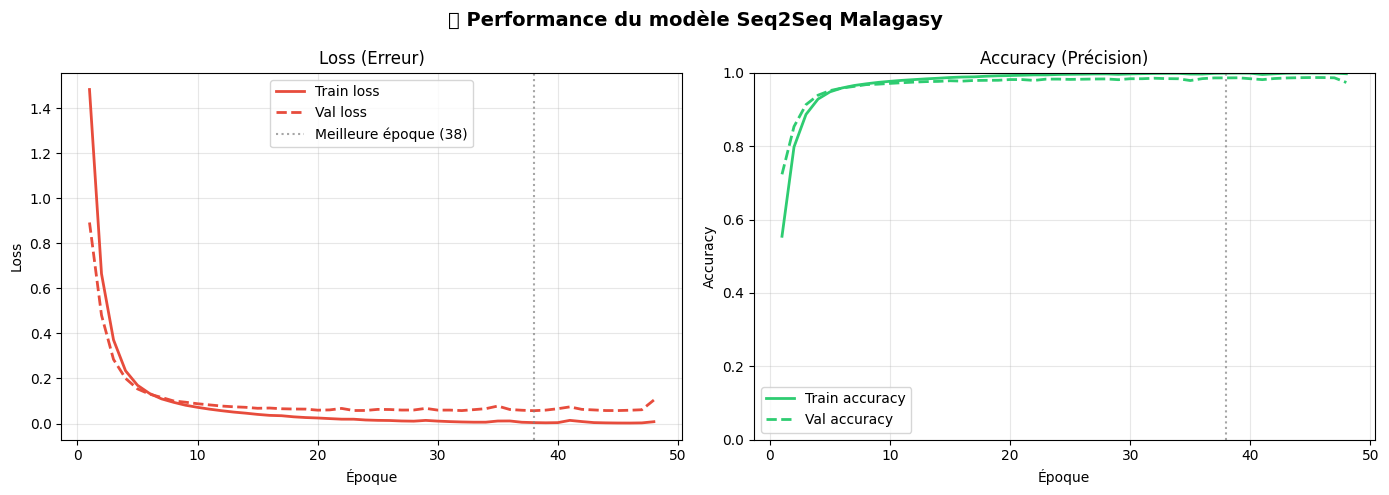


  📈 RÉSUMÉ DES PERFORMANCES
  Meilleure époque       : 38
  Meilleur val_loss      : 0.0570
  Meilleur val_accuracy  : 98.72%
  Train accuracy finale  : 99.75%
  Val accuracy finale    : 97.37%


In [8]:

# ── 1. Sauvegarder l'historique sur disque ────────────────────────────────────
with open('training_history.json', 'w') as f:
    json.dump(history.history, f)
print("✅ Historique sauvegardé dans training_history.json")

# ── 2. Charger l'historique (utile si on recharge le notebook sans réentraîner)
# with open('training_history.json') as f:
#     hist = json.load(f)
hist = history.history

epochs = range(1, len(hist['loss']) + 1)

# ── 3. Affichage ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("📊 Performance du modèle Seq2Seq Malagasy", fontsize=14, fontweight='bold')

# --- Courbe de LOSS ---
axes[0].plot(epochs, hist['loss'],     color='#e74c3c', linewidth=2, label='Train loss')
axes[0].plot(epochs, hist['val_loss'], color='#e74c3c', linewidth=2, linestyle='--', label='Val loss')
axes[0].set_title("Loss (Erreur)")
axes[0].set_xlabel("Époque")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Meilleure époque (val_loss min)
best_epoch = hist['val_loss'].index(min(hist['val_loss'])) + 1
axes[0].axvline(best_epoch, color='gray', linestyle=':', alpha=0.7, label=f'Meilleure époque ({best_epoch})')
axes[0].legend()

# --- Courbe d'ACCURACY ---
axes[1].plot(epochs, hist['accuracy'],     color='#2ecc71', linewidth=2, label='Train accuracy')
axes[1].plot(epochs, hist['val_accuracy'], color='#2ecc71', linewidth=2, linestyle='--', label='Val accuracy')
axes[1].set_title("Accuracy (Précision)")
axes[1].set_xlabel("Époque")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim([0, 1])
axes[1].axvline(best_epoch, color='gray', linestyle=':', alpha=0.7)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 4. Résumé chiffré ─────────────────────────────────────────────────────────
print(f"\n{'='*50}")
print(f"  📈 RÉSUMÉ DES PERFORMANCES")
print(f"{'='*50}")
print(f"  Meilleure époque       : {best_epoch}")
print(f"  Meilleur val_loss      : {min(hist['val_loss']):.4f}")
print(f"  Meilleur val_accuracy  : {max(hist['val_accuracy'])*100:.2f}%")
print(f"  Train accuracy finale  : {hist['accuracy'][-1]*100:.2f}%")
print(f"  Val accuracy finale    : {hist['val_accuracy'][-1]*100:.2f}%")
print(f"{'='*50}")


## 🧪 4. Inférence (Test avec racines)

In [12]:
import tensorflow as tf
import numpy as np

# ── 1. Charger le modèle complet ──────────────────────────────────────────────
model_saved = tf.keras.models.load_model('models/malagasy_morpheme_model_tagged.keras')

# Inspecter les couches pour retrouver les bons noms
for i, layer in enumerate(model_saved.layers):
    print(f"[{i}] {layer.name} — {type(layer).__name__}")

[0] input_layer — InputLayer
[1] input_layer_1 — InputLayer
[2] embedding — Embedding
[3] embedding_1 — Embedding
[4] lstm — LSTM
[5] lstm_1 — LSTM
[6] dense — Dense


In [13]:
def predict(word):
    # Vectorisation du mot
    input_seq = [[char2idx.get(char, 0) for char in str(word).lower()]]
    input_seq = tf.keras.preprocessing.sequence.pad_sequences(
        input_seq, maxlen=MAX_LEN_IN, padding='post'
    )
    
    # Encodeur → états [h, c]
    states = encoder_model.predict(input_seq, verbose=0)
    
    # Initialisation décodeur avec <SOS>
    target = np.zeros((1, 1))
    target[0, 0] = char2idx['<SOS>']
    
    result = ""
    for _ in range(MAX_LEN_OUT):
        tokens, h, c = decoder_model.predict(
            [target, states[0], states[1]], verbose=0
        )
        
        idx  = np.argmax(tokens[0, -1, :])
        char = idx2char[idx]
        
        if char == '<EOS>':
            break
        
        result += char
        target[0, 0] = idx
        states = [h, c]
    
    return result.replace("|", " - ")


In [16]:
# ── 2. Reconstruire encoder_model ────────────────────────────────────────────
encoder_inputs = model_saved.input[0]  # input_layer

encoder_lstm = model_saved.get_layer('lstm')          # ← était 'lstm_2'
encoder_output = encoder_lstm(model_saved.get_layer('embedding').output)  # ← était 'embedding_2'

# On récupère uniquement les états [h, c], pas la séquence
state_h = encoder_lstm.output[1]
state_c = encoder_lstm.output[2]

encoder_model = tf.keras.Model(
    inputs=encoder_inputs,
    outputs=[state_h, state_c]
)

# ── 3. Reconstruire decoder_model ────────────────────────────────────────────
decoder_inputs = model_saved.input[1]  # input_layer_1

LSTM_UNITS = model_saved.get_layer('lstm').output[1].shape[-1]  # ← était 'lstm_2'
print(f"LSTM units détectés : {LSTM_UNITS}")

decoder_state_input_h = tf.keras.Input(shape=(LSTM_UNITS,), name='input_h')
decoder_state_input_c = tf.keras.Input(shape=(LSTM_UNITS,), name='input_c')
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

decoder_lstm  = model_saved.get_layer('lstm_1')       # ← était 'lstm_3'
decoder_embed = model_saved.get_layer('embedding_1')  # ← était 'embedding_3'

dec_emb = decoder_embed(decoder_inputs)
dec_out, dec_h, dec_c = decoder_lstm(
    dec_emb,
    initial_state=decoder_states_inputs
)

decoder_dense   = model_saved.get_layer('dense')      # ← était 'dense_1'
decoder_outputs = decoder_dense(dec_out)

decoder_model = tf.keras.Model(
    inputs=[decoder_inputs] + decoder_states_inputs,
    outputs=[decoder_outputs, dec_h, dec_c]
)

# ── 4. Test rapide ────────────────────────────────────────────────────────────
test_samples = ["fahatany", "mahery", "mahakasika"]

print("✅ encoder_model et decoder_model reconstruits !")

for word in test_samples:
    res = predict(word)
    print(f"🔹 {word} ➔ {res}")


LSTM units détectés : 256
✅ encoder_model et decoder_model reconstruits !
🔹 fahatany ➔ faha - [tany]
🔹 mahery ➔ ma - [hery]
🔹 mahakasika ➔ maha - [kasika]


  🇲🇬  MALAGASY MORPHÈME — STATISTIQUES DU MODÈLE

📐 Architecture du modèle

          Couche        Type Output Shape  Paramètres
1    input_layer  InputLayer          N/A           0
2  input_layer_1  InputLayer          N/A           0
3      embedding   Embedding          N/A        1856
4    embedding_1   Embedding          N/A        1856
5           lstm        LSTM          N/A      328704
6         lstm_1        LSTM          N/A      328704
7          dense       Dense          N/A        7453

  Total paramètres : 668,573
  Couches          : 7

  🔤  VOCABULAIRE


              Métrique  Valeur
1         Tokens total      29
2   Caractères uniques      26
3      Tokens spéciaux       3
4  Longueur max entrée      22
5  Longueur max sortie      32

  Tokens spéciaux : <PAD>, <SOS>, <EOS>
  Caractères      : " [ ] a b d e f g h i j k l m n o p r s t v y z | ỳ


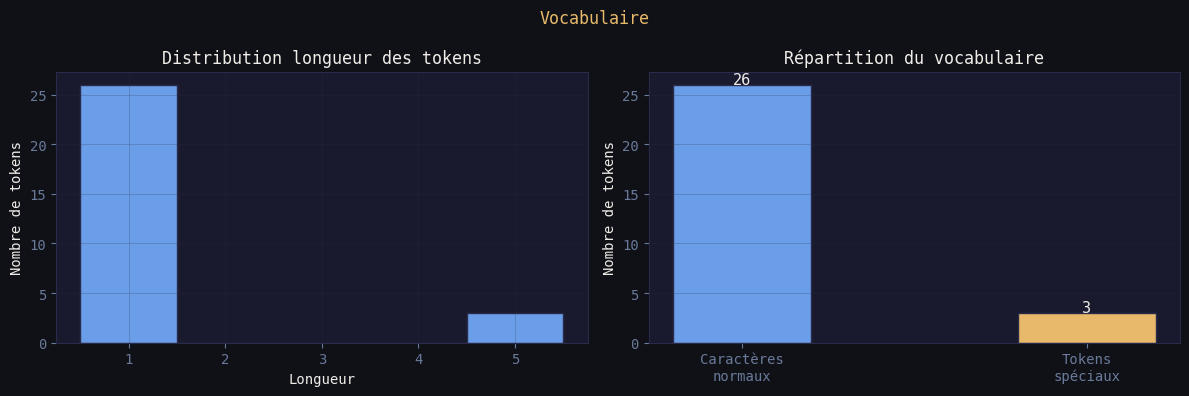


  ⚠️  history vide ou non disponible — relance model.fit() avec : history = model.fit(...)

  🔍  EXEMPLES DE PRÉDICTIONS


          Mot Morphèmes prédits Statut
1    fahatany     faha - [tany]      ✅
2      mahery       ma - [hery]      ✅
3  mahakasika   maha - [kasika]      ✅

  Fin du dashboard


In [17]:
## 📊 CELLULE STATS — Dashboard Malagasy (pandas + matplotlib uniquement)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':  '#0f1117',
    'axes.facecolor':    '#1a1a2e',
    'axes.edgecolor':    '#2a2a4a',
    'axes.labelcolor':   '#f0ede8',
    'xtick.color':       '#6a7a9a',
    'ytick.color':       '#6a7a9a',
    'text.color':        '#f0ede8',
    'grid.color':        '#2a2a4a',
    'grid.linewidth':    0.5,
    'font.family':       'monospace',
})

# ════════════════════════════════════════════════════════════════════════════
# 1. ARCHITECTURE DU MODÈLE
# ════════════════════════════════════════════════════════════════════════════
print("=" * 55)
print("  🇲🇬  MALAGASY MORPHÈME — STATISTIQUES DU MODÈLE")
print("=" * 55)

rows = []
for layer in model_saved.layers:
    try:
        params = layer.count_params()
    except:
        params = 0
    try:
        shape = str(layer.output_shape)
    except AttributeError:
        shape = 'N/A'
    rows.append({
        'Couche'      : layer.name,
        'Type'        : type(layer).__name__,
        'Output Shape': shape,
        'Paramètres'  : params,
    })

df_arch = pd.DataFrame(rows)
df_arch.index += 1

print("\n📐 Architecture du modèle\n")
print(df_arch.to_string())
print(f"\n  Total paramètres : {model_saved.count_params():,}")
print(f"  Couches          : {len(model_saved.layers)}")


# ════════════════════════════════════════════════════════════════════════════
# 2. VOCABULAIRE
# ════════════════════════════════════════════════════════════════════════════
if 'char2idx' in globals():
    print("\n" + "=" * 55)
    print("  🔤  VOCABULAIRE")
    print("=" * 55)

    special = [c for c in char2idx if c in ['<SOS>', '<EOS>', '<PAD>']]
    chars   = sorted([c for c in char2idx if c not in special])

    df_vocab = pd.DataFrame([
        {'Métrique': 'Tokens total',        'Valeur': len(char2idx)},
        {'Métrique': 'Caractères uniques',  'Valeur': len(chars)},
        {'Métrique': 'Tokens spéciaux',     'Valeur': len(special)},
        {'Métrique': 'Longueur max entrée', 'Valeur': MAX_LEN_IN  if 'MAX_LEN_IN'  in globals() else 'N/A'},
        {'Métrique': 'Longueur max sortie', 'Valeur': MAX_LEN_OUT if 'MAX_LEN_OUT' in globals() else 'N/A'},
    ])
    df_vocab.index += 1

    print("\n")
    print(df_vocab.to_string())
    print(f"\n  Tokens spéciaux : {', '.join(special)}")
    print(f"  Caractères      : {' '.join(chars)}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle('Vocabulaire', color='#e8b96a', fontsize=12)

    lengths = [len(c) for c in char2idx.keys()]
    axes[0].hist(lengths, bins=range(1, max(lengths)+2),
                 color='#6a9ee8', edgecolor='#2a2a4a', align='left')
    axes[0].set_title('Distribution longueur des tokens', color='#f0ede8')
    axes[0].set_xlabel('Longueur')
    axes[0].set_ylabel('Nombre de tokens')
    axes[0].grid(True, alpha=0.3)

    labels = ['Caractères\nnormaux', 'Tokens\nspéciaux']
    sizes  = [len(chars), len(special)]
    axes[1].bar(labels, sizes, color=['#6a9ee8', '#e8b96a'], edgecolor='#2a2a4a', width=0.4)
    axes[1].set_title('Répartition du vocabulaire', color='#f0ede8')
    axes[1].set_ylabel('Nombre de tokens')
    axes[1].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(sizes):
        axes[1].text(i, v + 0.1, str(v), ha='center', color='#f0ede8', fontsize=11)

    plt.tight_layout()
    plt.show()


# ════════════════════════════════════════════════════════════════════════════
# 3. COURBES D'ENTRAÎNEMENT
# ════════════════════════════════════════════════════════════════════════════

# Détection robuste du format history
def _parse_history(h):
    if hasattr(h, 'history'):
        hist = h.history
    elif isinstance(h, dict):
        hist = h
    else:
        hist = {}
    return hist if 'loss' in hist and len(hist['loss']) > 0 else None

hist = _parse_history(history) if 'history' in globals() else None

if hist:
    print("\n" + "=" * 55)
    print("  📈  COURBES D'ENTRAÎNEMENT")
    print("=" * 55)

    epochs  = range(1, len(hist['loss']) + 1)
    df_hist = pd.DataFrame({'Époque': list(epochs), 'Loss': hist['loss']})

    if 'val_loss' in hist:
        df_hist['Val Loss'] = hist['val_loss']

    acc_key = next((k for k in ['accuracy', 'sparse_categorical_accuracy'] if k in hist), None)
    if acc_key:
        df_hist['Accuracy']     = hist[acc_key]
        df_hist['Val Accuracy'] = hist[f'val_{acc_key}']

    df_hist = df_hist.set_index('Époque')
    print("\n")
    print(df_hist.round(4).to_string())

    if 'Val Loss' in df_hist:
        best_epoch = df_hist['Val Loss'].idxmin()
        print(f"\n  ✅ Meilleur epoch : {best_epoch}  |  Val Loss : {df_hist.loc[best_epoch,'Val Loss']:.4f}")

    n_plots = 2 if acc_key else 1
    fig, axes = plt.subplots(1, n_plots, figsize=(12 if n_plots == 2 else 6, 4))
    if n_plots == 1:
        axes = [axes]

    fig.suptitle("Courbes d'entraînement", color='#e8b96a', fontsize=12)

    axes[0].plot(list(epochs), hist['loss'],     color='#e8b96a', linewidth=2, label='Train loss')
    if 'val_loss' in hist:
        axes[0].plot(list(epochs), hist['val_loss'], color='#6a9ee8', linewidth=2,
                     linestyle='--', label='Val loss')
        axes[0].fill_between(list(epochs), hist['val_loss'], alpha=0.08, color='#6a9ee8')
        if 'Val Loss' in df_hist:
            axes[0].axvline(x=best_epoch, color='#6ae8a0', linewidth=1, linestyle=':')
    axes[0].fill_between(list(epochs), hist['loss'], alpha=0.08, color='#e8b96a')
    axes[0].set_title('Loss', color='#f0ede8')
    axes[0].set_xlabel('Époque')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    if acc_key:
        axes[1].plot(list(epochs), hist[acc_key],          color='#e8b96a', linewidth=2, label='Train acc')
        axes[1].plot(list(epochs), hist[f'val_{acc_key}'], color='#6a9ee8', linewidth=2,
                     linestyle='--', label='Val acc')
        axes[1].fill_between(list(epochs), hist[acc_key],          alpha=0.08, color='#e8b96a')
        axes[1].fill_between(list(epochs), hist[f'val_{acc_key}'], alpha=0.08, color='#6a9ee8')
        axes[1].set_title('Accuracy', color='#f0ede8')
        axes[1].set_xlabel('Époque')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_ylim(0, 1.05)
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

else:
    print("\n  ⚠️  history vide ou non disponible — relance model.fit() avec : history = model.fit(...)")


# ════════════════════════════════════════════════════════════════════════════
# 4. EXEMPLES DE PRÉDICTIONS
# ════════════════════════════════════════════════════════════════════════════
if 'predict' in globals():
    print("\n" + "=" * 55)
    print("  🔍  EXEMPLES DE PRÉDICTIONS")
    print("=" * 55)

    samples = test_samples if 'test_samples' in globals() else \
              ["miaboabo", "fahatany", "homady", "akasy", "mahakasy"]

    rows = []
    for word in samples:
        try:
            res = predict(word)
            rows.append({'Mot': word, 'Morphèmes prédits': res, 'Statut': '✅'})
        except Exception as e:
            rows.append({'Mot': word, 'Morphèmes prédits': str(e), 'Statut': '❌'})

    df_pred = pd.DataFrame(rows)
    df_pred.index += 1
    print("\n")
    print(df_pred.to_string())

print("\n" + "=" * 55)
print("  Fin du dashboard")
print("=" * 55)

In [18]:
## 🇲🇬 CELLULE GUI — Interface Malagasy Morphème Predictor
## Colle ce code dans une nouvelle cellule et exécute-la

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# ── Styles CSS injectés ──────────────────────────────────────────────────────
display(HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=DM+Mono:wght@400;500&family=Playfair+Display:wght@700&display=swap');

.mg-card {
    background: linear-gradient(135deg, #0f1117 0%, #1a1a2e 100%);
    border: 1px solid #2a2a4a;
    border-radius: 16px;
    padding: 2rem 2.5rem;
    max-width: 600px;
    margin: 1rem auto;
    font-family: 'DM Mono', monospace;
    box-shadow: 0 8px 40px rgba(106,158,232,0.08), 0 0 0 1px rgba(232,185,106,0.05);
}

.mg-title {
    font-family: 'Playfair Display', serif;
    font-size: 1.6rem;
    color: #e8b96a;
    text-align: center;
    margin-bottom: 0.3rem;
    letter-spacing: 0.02em;
}

.mg-subtitle {
    text-align: center;
    color: #6a7a9a;
    font-size: 0.75rem;
    margin-bottom: 1.8rem;
    letter-spacing: 0.1em;
    text-transform: uppercase;
}

.mg-result-box {
    background: #0a0a12;
    border: 1px solid #2a2a4a;
    border-left: 3px solid #e8b96a;
    border-radius: 10px;
    padding: 1.2rem 1.5rem;
    margin-top: 1.5rem;
    font-family: 'DM Mono', monospace;
}

.mg-result-label {
    font-size: 0.65rem;
    color: #6a7a9a;
    text-transform: uppercase;
    letter-spacing: 0.12em;
    margin-bottom: 0.5rem;
}

.mg-result-word {
    font-size: 1rem;
    color: #a0b4d0;
    margin-bottom: 0.3rem;
}

.mg-result-arrow {
    color: #e8b96a;
    margin: 0 0.5rem;
}

.mg-result-morpheme {
    font-size: 1.2rem;
    color: #e8f4ff;
    font-weight: 500;
    letter-spacing: 0.05em;
}

.mg-history-item {
    display: flex;
    align-items: center;
    gap: 0.5rem;
    padding: 0.5rem 0;
    border-bottom: 1px solid #1a1a2e;
    font-size: 0.85rem;
}

.mg-history-item:last-child { border-bottom: none; }

.mg-error {
    border-left-color: #e86a6a !important;
}

.mg-error .mg-result-morpheme {
    color: #e86a6a;
}

.mg-badge {
    display: inline-block;
    background: rgba(232,185,106,0.12);
    color: #e8b96a;
    border-radius: 4px;
    padding: 0.1rem 0.5rem;
    font-size: 0.7rem;
    letter-spacing: 0.08em;
}
</style>
"""))

# ── En-tête ──────────────────────────────────────────────────────────────────
display(HTML("""
<div class="mg-card">
    <div class="mg-title">🇲🇬 Analyseur Morphologique</div>
    <div class="mg-subtitle">Malagasy · Seq2Seq · Prédiction de morphèmes</div>
</div>
"""))

# ── Widgets ──────────────────────────────────────────────────────────────────
input_word = widgets.Text(
    placeholder='Ex: miaboabo, fahatany, mahakasy...',
    layout=widgets.Layout(width='100%', height='42px'),
    style={'font_size': '14px'}
)

btn_predict = widgets.Button(
    description='Analyser ➔',
    button_style='',
    layout=widgets.Layout(width='140px', height='42px'),
    style={'button_color': '#1a1a2e', 'font_weight': 'bold'}
)

btn_clear = widgets.Button(
    description='Effacer',
    button_style='',
    layout=widgets.Layout(width='100px', height='42px'),
    style={'button_color': '#0a0a12'}
)

# Zone de résultat principal
output_main = widgets.Output()

# Zone historique
output_history = widgets.Output()

# Historique stocké en mémoire
history = []

# ── Logique ──────────────────────────────────────────────────────────────────
def on_predict(b):
    word = input_word.value.strip()
    if not word:
        return

    with output_main:
        clear_output(wait=True)
        display(HTML('<div class="mg-result-box"><div class="mg-result-label">Traitement...</div></div>'))

    try:
        result = predict(word)   # ← appel à ta fonction predict() existante
        is_error = False
    except Exception as e:
        result = f"Erreur : {e}"
        is_error = True

    error_class = "mg-error" if is_error else ""

    with output_main:
        clear_output(wait=True)
        display(HTML(f"""
        <div class="mg-card" style="margin-top:0">
            <div class="mg-result-box {error_class}">
                <div class="mg-result-label">Résultat</div>
                <div>
                    <span class="mg-result-word">{word}</span>
                    <span class="mg-result-arrow">➔</span>
                    <span class="mg-result-morpheme">{result}</span>
                </div>
            </div>
        </div>
        """))

    # Ajouter à l'historique
    if not is_error:
        history.insert(0, (word, result))
        if len(history) > 8:
            history.pop()

        with output_history:
            clear_output(wait=True)
            items_html = "".join([
                f'<div class="mg-history-item">'
                f'<span style="color:#6a9ee8">{w}</span>'
                f'<span style="color:#e8b96a;margin:0 6px">➔</span>'
                f'<span style="color:#e0e0f0">{r}</span>'
                f'</div>'
                for w, r in history
            ])
            display(HTML(f"""
            <div class="mg-card" style="margin-top:0">
                <div style="font-size:0.7rem;color:#6a7a9a;text-transform:uppercase;
                            letter-spacing:0.1em;margin-bottom:1rem">
                    Historique <span class="mg-badge">{len(history)}</span>
                </div>
                {items_html}
            </div>
            """))

def on_clear(b):
    input_word.value = ''
    history.clear()
    with output_main:
        clear_output()
    with output_history:
        clear_output()

# Permettre validation avec Entrée
def on_enter(widget):
    on_predict(None)

btn_predict.on_click(on_predict)
btn_clear.on_click(on_clear)
input_word.on_submit(on_enter)

# ── Layout final ─────────────────────────────────────────────────────────────
row = widgets.HBox(
    [input_word, btn_predict, btn_clear],
    layout=widgets.Layout(gap='8px', width='100%', max_width='600px', margin='0 auto')
)

display(widgets.VBox(
    [row, output_main, output_history],
    layout=widgets.Layout(width='100%', max_width='620px', margin='0 auto', gap='4px')
))